# 03 — Model Training v5 (1D CNN, 10 activities, deployable)

Simple 1D CNN with legacy Adam optimizer. Global normalization only — matches device exactly.

In [1]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers, callbacks
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.13.0


In [2]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models/v5')
RESULTS_DIR = Path('../results/v5')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')
X_train_orig = np.load(DATA_DIR / 'X_train_original.npy')

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

NUM_CLASSES = info['num_classes']
WINDOW_SIZE = info['window_size']
NUM_FEATURES = info['num_features']
ACTIVITIES = info['activities']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Classes: {NUM_CLASSES} | Features: {NUM_FEATURES}')
print(f'Activities: {ACTIVITIES}')
print(f'Dropped: {info.get("dropped_activities", [])}')
print(f'Saving to: {MODEL_DIR} and {RESULTS_DIR}')

Train: (27036, 128, 8) | Test: (922, 128, 8)
Classes: 10 | Features: 8
Activities: ['ear_rubbing', 'forehead_rubbing', 'hair_pulling', 'hand_tapping', 'knuckles_cracking', 'nail_biting', 'nape_rubbing', 'sitting', 'smoking', 'standing']
Dropped: ['hand_scratching']
Saving to: ../models/v5 and ../results/v5


## 1D CNN Architecture

In [3]:
def build_1dcnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, kernel_size=3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='CNN_1D')

print('1D CNN ready.')

1D CNN ready.


## Train

In [4]:
EPOCHS = 100
BATCH_SIZE = 64

cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: w for i, w in enumerate(cw_arr)}

model = build_1dcnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()
print(f'\nParameters: {model.count_params():,}')
print(f'Classes: {NUM_CLASSES} | Epochs: {EPOCHS}')

2026-05-15 14:23:18.800244: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-15 14:23:18.800541: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-15 14:23:18.801748: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-15 14:23:18.802345: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-15 14:23:18.802843: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "CNN_1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 8)]          0         
                                                                 
 conv1d (Conv1D)             (None, 128, 32)           800       
                                                                 
 batch_normalization (Batch  (None, 128, 32)           128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 128, 32)           0         
                                                                 
 max_pooling1d (MaxPooling1  (None, 64, 32)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 64, 32)            0    

In [5]:
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_1dcnn_v5.h5'), monitor='val_loss',
                                  save_best_only=True, verbose=0),
    ],
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nFinal Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

Epoch 1/100


2026-05-15 14:23:28.150500: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


360/360 [==============================] - ETA: 0s - loss: 1.2400 - accuracy: 0.5443

2026-05-15 14:23:33.864064: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


360/360 [==============================] - 7s 14ms/step - loss: 1.2400 - accuracy: 0.5443 - val_loss: 0.8846 - val_accuracy: 0.6876 - lr: 0.0010
Epoch 2/100
360/360 [==============================] - 4s 12ms/step - loss: 0.8689 - accuracy: 0.6775 - val_loss: 0.7087 - val_accuracy: 0.7409 - lr: 0.0010
Epoch 3/100
360/360 [==============================] - 5s 13ms/step - loss: 0.7358 - accuracy: 0.7249 - val_loss: 0.6255 - val_accuracy: 0.7663 - lr: 0.0010
Epoch 4/100
360/360 [==============================] - 4s 12ms/step - loss: 0.6886 - accuracy: 0.7447 - val_loss: 0.6062 - val_accuracy: 0.7719 - lr: 0.0010
Epoch 5/100
360/360 [==============================] - 4s 12ms/step - loss: 0.6623 - accuracy: 0.7583 - val_loss: 0.5323 - val_accuracy: 0.7968 - lr: 0.0010
Epoch 6/100
360/360 [==============================] - 5s 13ms/step - loss: 0.6334 - accuracy: 0.7692 - val_loss: 0.5239 - val_accuracy: 0.8060 - lr: 0.0010
Epoch 7/100
360/360 [==============================] - 5s 13ms/step - 

## Results

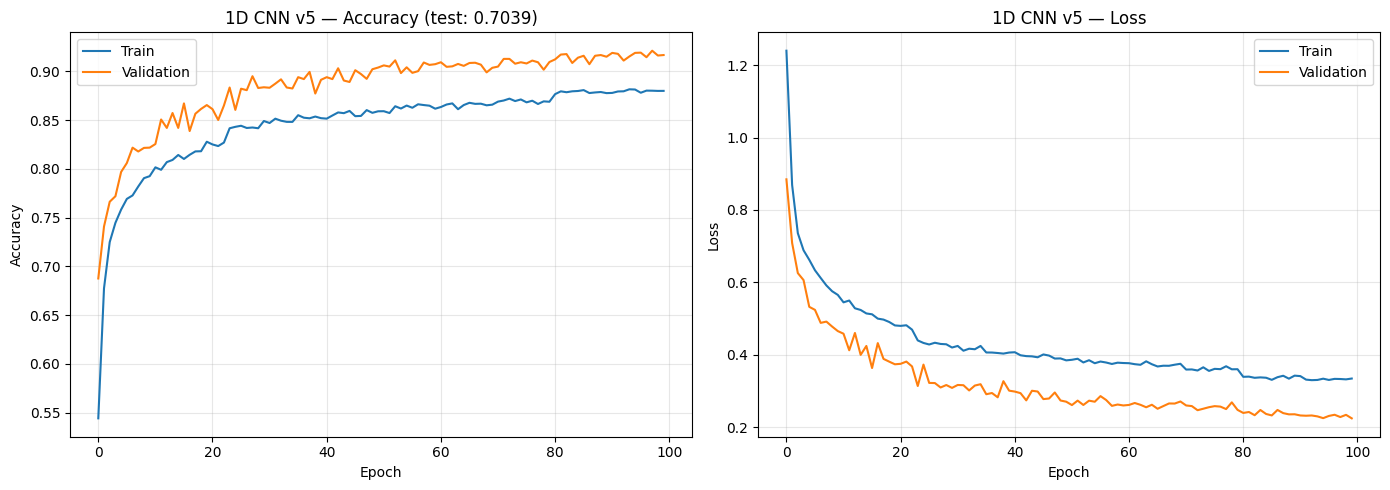

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title(f'1D CNN v5 — Accuracy (test: {test_acc:.4f})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('1D CNN v5 — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '1dcnn_v5_training_history.png', dpi=150)
plt.show()

2026-05-15 14:31:19.803003: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


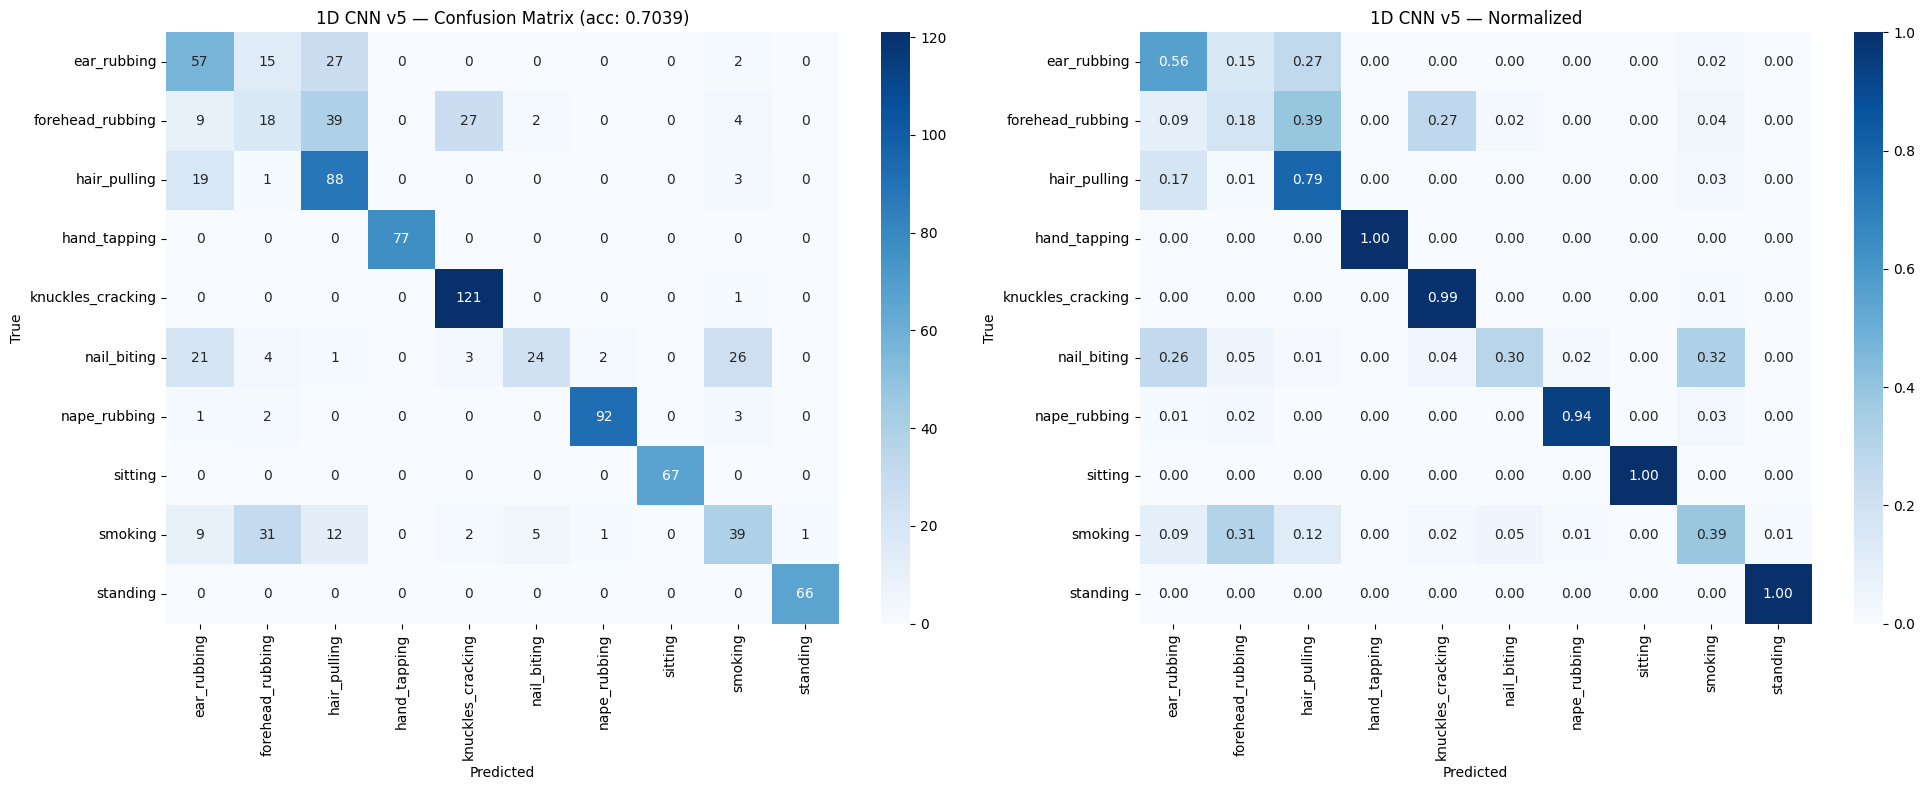

                   precision    recall  f1-score   support

      ear_rubbing     0.4914    0.5644    0.5253       101
 forehead_rubbing     0.2535    0.1818    0.2118        99
     hair_pulling     0.5269    0.7928    0.6331       111
     hand_tapping     1.0000    1.0000    1.0000        77
knuckles_cracking     0.7908    0.9918    0.8800       122
      nail_biting     0.7742    0.2963    0.4286        81
     nape_rubbing     0.9684    0.9388    0.9534        98
          sitting     1.0000    1.0000    1.0000        67
          smoking     0.5000    0.3900    0.4382       100
         standing     0.9851    1.0000    0.9925        66

         accuracy                         0.7039       922
        macro avg     0.7290    0.7156    0.7063       922
     weighted avg     0.7010    0.7039    0.6867       922



In [7]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax1)
ax1.set_title(f'1D CNN v5 — Confusion Matrix (acc: {test_acc:.4f})')
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax2)
ax2.set_title('1D CNN v5 — Normalized')
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '1dcnn_v5_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=ACTIVITIES, digits=4))

## Comparison

In [8]:
print(f'1D CNN v5 — Test accuracy: {test_acc:.4f}')
print(f'Parameters: {model.count_params():,}')

1D CNN v5 — Test accuracy: 0.7039
Parameters: 24,810


## Save

In [9]:
model.save(MODEL_DIR / 'best_model_v5.h5')

DEPLOY_DIR = Path('../models')

training_info = {
    'best_model': '1DCNN_v5',
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'num_classes': NUM_CLASSES,
    'activities': ACTIVITIES,
    'window_size': WINDOW_SIZE,
    'num_features': NUM_FEATURES,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'class_weights': class_weights,
    'history': history.history,
    'params': model.count_params(),
}

with open(MODEL_DIR / 'training_info_v5.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f'Model saved to {MODEL_DIR}/best_model_v5.h5')
print(f'Parameters: {model.count_params():,}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'\nNext: run 04_quantization_v5.ipynb')

Model saved to ../models/v5/best_model_v5.h5
Parameters: 24,810
Test accuracy: 0.7039

Next: run 04_quantization_v5.ipynb
